# Dashboard of Millionærklubben portfolios 
- a cronjob downloads each day the portfolios into a CSV from https://www.home.saxo/da-dk/campaigns/millionaerklubben
- this notebook turns the CSV files into a visual representation
- we also calculate returns, however, without cash data this is only based on the stock valu, because the cash number gets not published
- run this as Streamlit app with `streamlit run <this file>`

In [1]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import dateutil.parser as dparser
import datetime as dt
import streamlit as st

import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.dates as mdates
import matplotlib.patches as patches

from mystocks import retrievals, conversions
import utils # in this folder

In [2]:
IN_NOTEBOOK = utils.in_notebook()
%matplotlib inline
if not IN_NOTEBOOK:
    st.set_page_config(layout="wide")

In [41]:
START_DATE = dt.datetime(2026,1,1)
today = dt.date.today()
yesterday = (today - dt.timedelta(days=1))
#round to decimals in pandas tables output
pd.options.display.float_format = '{:,.2f}'.format

mycolors=[
        "#0068c9",
        "#83c9ff",
        "#ff2b2b",
        "#ffabab",
        "#29b09d",
        "#7defa1",
        "#ff8700",
        "#ffd16a",
        "#6d3fc0",
        "#d5dae5",
    ]

In [42]:
from pathlib import Path
## modern way is to use pathlib instead of "import os" and string path
if not IN_NOTEBOOK:
    BASE_PATH = Path(__file__).resolve().parent
else:
    BASE_PATH = Path("__file__").resolve().parent
DATA_PATH = BASE_PATH / "data"
csv_files = list(DATA_PATH.glob("*.csv"))

DB_PATH = DATA_PATH / 'MK_PRICES.db'

#print("Data path is", DATA_PATH)
#print("SQL path is", DB_PATH)
#print("CSV files are", csv_files)

# Style prep

In [43]:
## STYLING
def color_value(val):
    if val >= 0:
        return("color: green;")
    if val < 0:
        return("color: red;")
    return("color: gray;")

style_format = {'InvestedDKK': 'DKK {:,.2f}', 
                'Days': '{:} d', 
                'PctReturns': '{:,.1f}%',
                'Return': '{:,.1f}%',
                'OpeningPrice': '{:,.2f}',
                'LastPrice': '{:,.2f}',
                'AfkastDKK':  'DKK {:,.2f}',
               }

# Data
## Get CSV downloads

In [44]:
## create dataframe from daily scraped website CSV files  
df = pd.DataFrame()
#dates = []
# loop over the list of csv files
for f in csv_files:
    # print the location and filename
    #print('Reading file:', f.split("\\")[-1]) #debug. Will be read in non-order. 
    x = pd.read_csv(f, sep=';', index_col=[0])
    # date parser from file name. No date in the CSV. Maybe add this in 2024?
    extracted_date = dparser.parse(f.name, fuzzy=True) 
    x['Date'] = extracted_date
    #dates.append(extracted_date.isoformat()) 
    df = pd.concat([x,df], axis=0)

df = df.drop_duplicates().reset_index(drop=True)

In [45]:
## cleanup
df_clean = utils.replace_b_suffix(df, 'Instrument')
df_clean = utils.replace_b_suffix(df_clean, 'Ticker')
df = df_clean.copy()

df = utils.cleanup_tickers_names(df).copy()

# Start website

In [46]:
if IN_NOTEBOOK == False:
    st.title("Millionærklubben portfolios")

In [47]:
#if not IN_NOTEBOOK:
#    st.dataframe(df)

In [48]:
last_date_in_df = df.Date.tail(1).iloc[0].strftime('%Y-%m-%d')
if IN_NOTEBOOK == False:
    t = "Today is: "+str(today)+" and last download date was: "+str(last_date_in_df)
    st.text(t)
    if str(today) == last_date_in_df:
        st.text('Nice, I have the most recent data!')
    else:
        st.text("NOTE! Update the CSV files!")

## FX for DKK conversion

In [49]:
## this is made during each websitedownload
#df['Amount'] = df.Antal * df.Åbningspris

fx = {'USD':7.058, 'EUR':7.456, 'DKK':1, 'SEK':0.645, 'AUD':4.49, 'CAD':5.19, 'NOK':0.657}

df['FX'] = df['Currency'].map(fx)

## Master df 'm' with all dates
- as of 2024: remove Mads Christensen, I do not find his strategy and actions relevant
- as of 2025: remove Anders Bæk (exited) 

In [50]:
## remove Mads Christiansen - since Jan 2024 anyway no longer in MK
my_investors = ['Lars Persson', 'Lau Svenssen', 'Michael Friis Jørgensen']
m = df.loc[df.Investor.isin(my_investors)].sort_values('Investor').sort_index()
#m.tail()
#m.loc[m.Instrument == 'SVITZR']
#Investor	Instrument	Antal	Åbningspris	Amount	Currency	Stockexchange	Ticker	FX	Date	BuyDate	LastSeen
m = m.rename(columns={'Åbningspris':'OpeningPrice', 'Antal':'Quantity'})

## Select Start Date

In [51]:
if IN_NOTEBOOK:
    sd = dt.datetime(2025,1,1)
else:
    sd = st.date_input("Start date of analysis", value=START_DATE, min_value=dt.datetime(2025,1,1), 
                   max_value=dt.datetime.today(), 
                   format="YYYY-MM-DD", disabled=False, label_visibility="visible")

# show table with the selected start date
m = m[m.Date >= pd.to_datetime(sd)]

# Group by 'Instrument' and find the first appearing and last date
## MAGIC !! first and last are applied functions??
buy_sell_dates = m.reset_index().groupby(['Investor','Instrument']).agg({'Date': ['first', 'last']})
buy_sell_dates.columns = buy_sell_dates.columns.droplevel(0)
buy_sell_dates = buy_sell_dates.rename(columns={'last':'LastSeen', 'first':'BuyDate'})
#buy_sell_dates.tail()

## add the first and last seen dates
mbs = m.set_index(['Investor', 'Instrument']).merge(
    buy_sell_dates, right_index=True, left_index=True, how='outer').reset_index()

## Prices
have this here, so the streamlit is loaded

In [52]:
prices = retrievals.sql_price(isin_list=list(m.Instrument.unique()), 
                              db_path=DB_PATH, columns=['close'])
prices = prices.sort_index()
prices.columns = prices.columns.str.rstrip('_close') 

## make consecutive, because I have some Buys that are on weekends (website update)
prices = conversions.create_full_date_df(prices, prices.index.name).loc[sd:] # also limit to selected date 'sd'

prices = prices.reindex(sorted(prices.columns), axis=1)

## create df that contains the FX for multiplying later with prices
fx_df = pd.DataFrame(data=m[['Instrument', 'FX']]).drop_duplicates().set_index('Instrument').sort_index()

INFO: Stock price dataframe from /home/pi/mynotebooks/mill_klubben/data/MK_PRICES.db has shape (4066, 39)


In [53]:
if IN_NOTEBOOK == False:
    if str(today) == prices.index.max().strftime('%Y-%m-%d'):
        st.text('Nice, I have the most recent stock price data!')
    else:
        st.text("NOTE! Update the CSV files!")
## multiplying did not work as I wanted, this is a method that works 
## IMPORTANT that the dfs are sorted and same length
dkk_prices = pd.DataFrame(prices.values*fx_df.T.values, columns=prices.columns, 
                          index=prices.index).dropna(how='all')
dkk_prices = conversions.create_full_date_df(dkk_prices, 'Date')

## Quantity

In [54]:
## create pivot df that has all stock quantity per date
q = mbs.pivot_table(index='Date', columns=['Investor', 'Instrument'], values='Quantity').sort_index().dropna(how='all', axis=1)
#q.tail()

## Value

In [55]:
## create value df and the sum of invested stocks per investor per date
## this is in stock currency still
value = q.multiply(dkk_prices, level=1, axis='columns').sort_index()
#value = conversions.create_full_date_df(value, 'Date').ffill()
#value_per_investor = value_per_investor.replace(0,np.nan).dropna()
value_group = value.T.groupby(level=0).sum().replace(0,np.nan)
value_per_investor = value_group.T.sort_index().ffill().loc[sd:]

In [56]:
## make some lists
all_tickers = df.Ticker.unique()
all_investors = df.Investor.unique()
## I originally deselected Mads Christiansen 
my_investors = m.Investor.unique()
my_tickers = m.Ticker.unique()
my_instruments = m.Instrument.unique()

# Plot Value of all portfolios

In [57]:
if IN_NOTEBOOK == False:
    st.subheader("Value of portfolios from all investors")

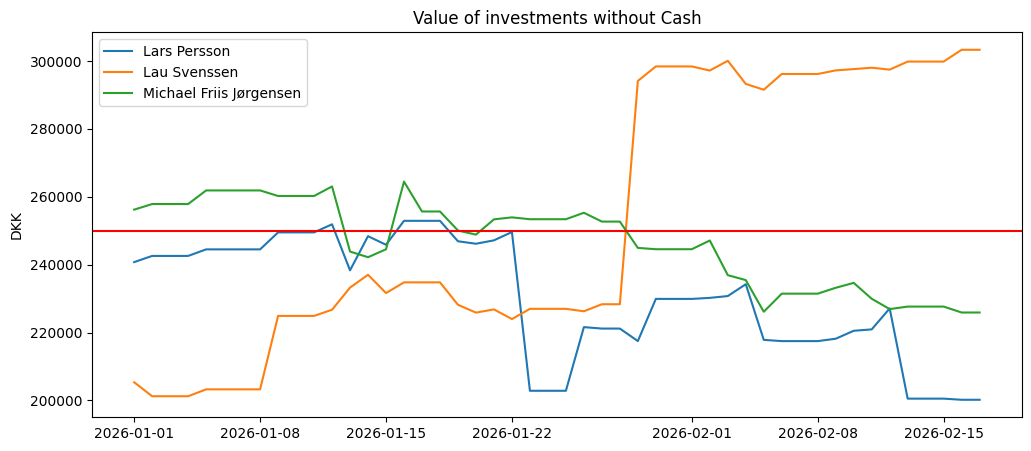

In [58]:
fig, ax = plt.subplots(figsize=[12,5])
ax.plot(value_per_investor)
ax.set_title('Value of investments without Cash')
ax.axhline(250000, color='r')
ax.legend(value_per_investor.columns)
ax.set_ylabel('DKK')
if IN_NOTEBOOK:
    fig.show();
else:
    st.pyplot(fig, width=1200)

In [59]:
## Now with all investors
curr_all = mbs.groupby(['Investor','Instrument']).last()
curr_all['InvestedDKK'] = curr_all.Amount * curr_all.FX

## this limits all transactions to the Date where the stock was sold OR where the stock is still held today
## you could call this the 'action list' of all investors
## at other "Date"s nothing really happened per stock, per investor
curr_all = curr_all.loc[curr_all.Date == curr_all['LastSeen']].reset_index()

In [60]:
for i in range(0, len(curr_all)):
    buy_price = prices.loc[curr_all.BuyDate[i], curr_all['Instrument'][i]]
    sell_price = prices.loc[curr_all.LastSeen[i], curr_all['Instrument'][i]]
    #print("Buy price of", trans.Instrument[i], "was", round(buy_price, 2), "on", trans.Buy[i])
    curr_all.loc[i, 'BuyPrice'] = buy_price
    curr_all.loc[i, 'LastPrice'] = sell_price
    curr_all.loc[i, 'Return'] = ( (float(sell_price)-buy_price) / buy_price)

# Percent returns
curr_all['PctReturns'] = curr_all.Return * 100
# This is a timedelta type
curr_all['DaysDelta'] = (curr_all.LastSeen - curr_all.BuyDate)
# Make sure Days and InvestedDKK are numeric and non-negative
curr_all['Days']  = curr_all['DaysDelta'].dt.days
## NVIDIA fix split during holding this stock
curr_all.loc[curr_all.Instrument == 'NVDA', 'BuyPrice' ] = curr_all['BuyPrice'].loc[curr_all.Instrument == 'NVDA'] /10 

curr_all['AfkastDKK'] = curr_all.InvestedDKK * curr_all.Return

# Force any negatives to zero (so matplotlib is happy)
curr_all.loc[curr_all["InvestedDKK"] < 0, "InvestedDKK"] = 0

In [61]:
## average holding time
average_holding_time = pd.DataFrame(curr_all.groupby(['Investor'])['DaysDelta'].mean().dt.days)
if IN_NOTEBOOK == False:
    st.dataframe(average_holding_time)

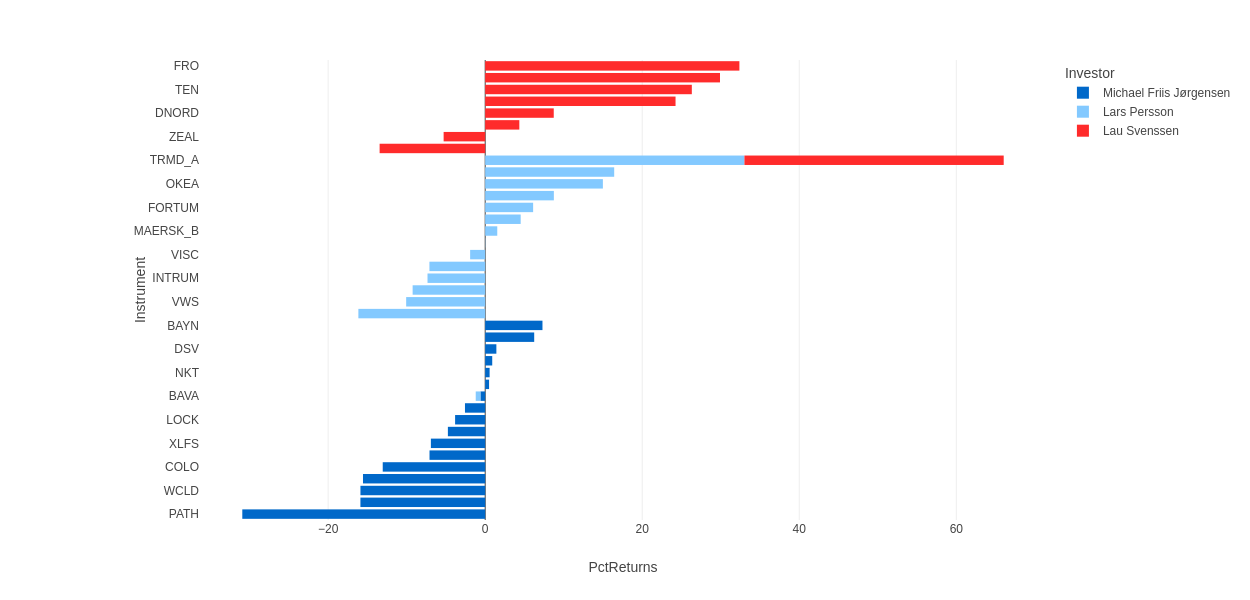

In [62]:
data = curr_all[['Investor','Instrument','PctReturns']].copy().sort_values('PctReturns')

## show plotly plot
fig = px.bar(data, x="PctReturns", y="Instrument", orientation='h', color='Investor', 
             hover_data=['PctReturns', 'Instrument'],
             color_discrete_sequence=mycolors, width=1000, height=600)
# overwrite tick labels    
fig.update_layout(
    yaxis = {
     'tickmode': 'array',
     #'tickvals': list(range(len(data.MyName))),
     'ticktext': data.Instrument.str.slice(stop=14).tolist()
    },
    margin=dict(l=200)
)

if IN_NOTEBOOK:
    fig.show()
else:
    st.plotly_chart(fig, width=800)

# Show Selected Investor

In [63]:
if IN_NOTEBOOK == False:
    st.sidebar.header("Drilldowns")
#st.sidebar.markdown("""
#Show the portfolio per Millionærklubben investor
#""")
if IN_NOTEBOOK:
    selected_investor = 'Lau Svenssen'
else:
    selected_investor = st.sidebar.selectbox('Select investor', my_investors)

In [64]:
## Show portfolio content
t = "Portfolio of " + selected_investor
if IN_NOTEBOOK == False:
    st.subheader(t, divider='rainbow')

In [65]:
## portfolio of selected investor
curr_si = curr_all.loc[(curr_all.Investor == selected_investor) & (curr_all.Quantity >0) &
                        (curr_all.LastSeen == curr_all.LastSeen.max())].copy()
data = curr_si[['Instrument', 'Quantity', 'OpeningPrice', 'InvestedDKK', 'Days', 'PctReturns', 'AfkastDKK']]

styled = data.style.map(color_value, subset=['AfkastDKK']).format(style_format)

if IN_NOTEBOOK == False:
    st.dataframe(data=styled, width=800)

## Figure: Invested and Afkast

In [66]:
# Plot the Buy and Sell bar chart
def plot_portfolio(curr_all, investor_colors, today):
    # --- Create instrument categories once, shared for both plots
    instruments = pd.Categorical(curr_all["Instrument"])
    curr_all = curr_all.assign(Instrument_idx=instruments.codes)
    
    fig = plt.figure(figsize=[14, 12])

    # --- Left plot: holding periods
    ax0 = plt.subplot(121)

    ax0.barh(
        y=curr_all["Instrument_idx"],
        width=curr_all["Days"],
        left=curr_all["BuyDate"],
        color=curr_all["Investor"].map(investor_colors)
    )

    ax0.set_title("Holding period")
    ax0.xaxis.set_major_locator(mdates.MonthLocator())
    ax0.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax0.set_xlabel("Timeline")

    ylim = ax0.get_ylim()
    ax0.vlines(today, 0, ylim[1]-2, colors="r") # line is a bit too long, because ylim is for some reason -3 to 58 (should be 0 to max-2)
    ax0.xaxis.grid(True, alpha=0.5)

    # --- Right plot: invested DKK
    ax1 = plt.subplot(122, sharey=ax0)

    # background bars
    ax1.barh(
        y=curr_all["Instrument_idx"],
        width=curr_all["InvestedDKK"] / 1000,
        color="grey",
        alpha=0.6
    )

    # overlay bars for current holdings
    latest = curr_all.LastSeen.max()
    curr_now = curr_all.loc[curr_all.LastSeen == latest]

    ax1.barh(
        y=curr_now["Instrument_idx"],
        width=curr_now["InvestedDKK"] / 1000,
        color=curr_now["Investor"].map(investor_colors),
        alpha=0.9
    )

    # Return labels
    offset = 0.2
    for xpos, ypos, ret in zip(
        curr_now["InvestedDKK"] / 1000 + offset,
        curr_now["Instrument_idx"],
        curr_now["PctReturns"]
    ):
        ax1.text(
            x=xpos,
            y=ypos,
            s=f"{ret:.1f}%",
            va="center",
            ha="left",
            fontsize=10,
            color="black"
        )

    ax1.set_title("Invested for DKK")
    ax1.xaxis.grid(True, alpha=0.5)
    ax1.yaxis.tick_right()
    ax1.set_xlabel("TDKK")

    # --- Shared y-axis labels
    ax0.set_yticks(range(len(instruments.categories)))
    ax0.set_yticklabels(instruments.categories)
    ax1.set_yticks(range(len(instruments.categories)))
    ax1.set_yticklabels(instruments.categories)

    # invert y to match your style
    ax0.invert_yaxis()

    # --- Legend
    patch = [patches.Patch(color=col, label=inv) for inv, col in investor_colors.items()]
    ax1.legend(handles=patch, fontsize=11)

    plt.tight_layout()
    return(fig)

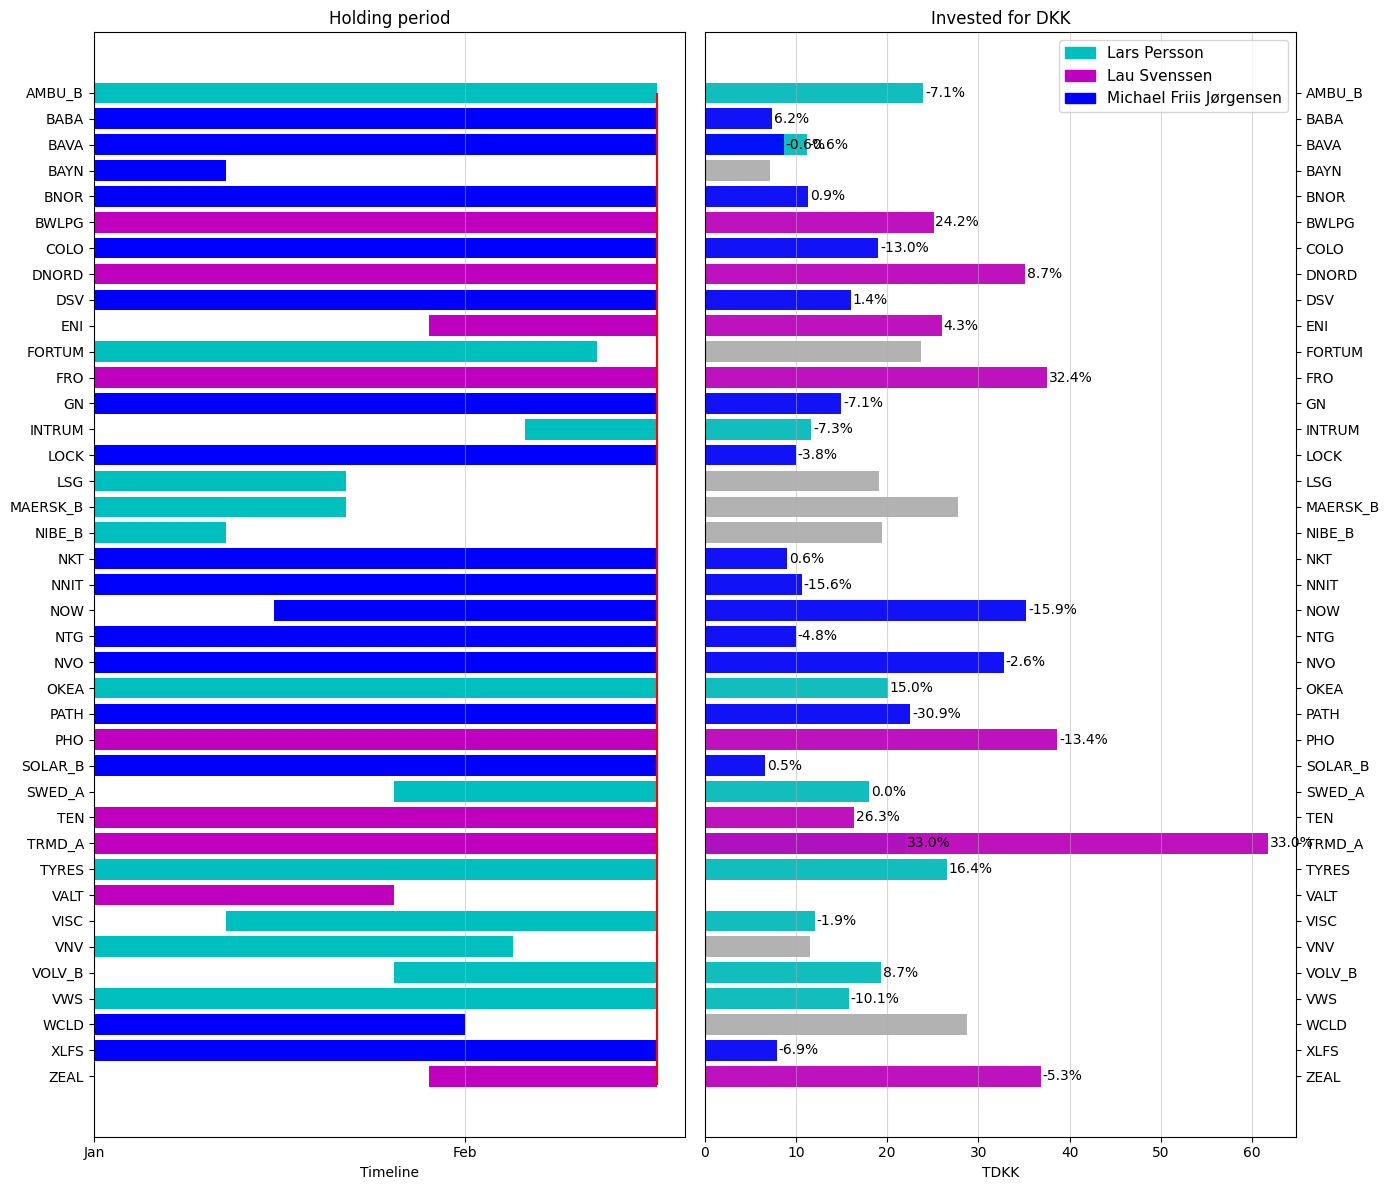

In [67]:
investor_colors = {'Lars Persson': 'c', 'Lau Svenssen': 'm',  'Michael Friis Jørgensen': 'b', }
fig = plot_portfolio(curr_all, investor_colors, today)

if IN_NOTEBOOK:
    fig.show()
else:
    st.pyplot(fig, width="content")

## Sold or bought during the last X days?

In [68]:
if IN_NOTEBOOK == False:
    st.header("Sold and Bought")

In [69]:
# get first and last datetime for final week of data
days = 14
## make df copy
bs = curr_all.copy()

range_max = bs['Date'].max()# the last time the CSV was extracted from the webpage
range_min = range_max - dt.timedelta(days=days) # X days earlier

# take slice with final week of data
rec_sold = bs[(bs['LastSeen'] >= range_min) &
              (bs['LastSeen'] <= range_max) &
#              (bs['Quantity'] == 0)# this gives the issue that not all sold have the next day a Quantity of 0
            (bs['Date']!= range_max)].reset_index(drop=True)
rec_sold['Return'] *= 100
rec_sold[['InvestedDKK', 'Return']] = round(rec_sold[['InvestedDKK', 'Return']],2)

In [70]:
range_max = bs['BuyDate'].max() + dt.timedelta(days=1) # that should be today, or yesterday, if the cronjob runs as expected and I run this in the evening or during the day, respectively
range_min = range_max - dt.timedelta(days=days)

# take slice with final week of data
rec_buy = bs[(bs['BuyDate'] >= range_min) & 
             (bs['BuyDate'] <= range_max) &
             (bs['Quantity'] > 0)].reset_index(drop=True)
rec_buy['Return'] *= 100
rec_buy[['InvestedDKK', 'Return']] = round(rec_buy[['InvestedDKK', 'Return']],2)

In [73]:
cols = ['Investor', 'Instrument', 'Days', 'Quantity', 'OpeningPrice', 'LastPrice', 'InvestedDKK', 'Return']
data_sold = rec_sold.loc[:, cols]
styled_sold = data_sold.style.map(color_value, subset=['Return']).format(style_format)
data_buy = rec_buy.loc[:, cols]
styled_buy = data_buy.style.map(color_value, subset=['Return']).format(style_format)

if IN_NOTEBOOK == False:
    st.text("Stocks that have been sold the last "+str(days)+" days:")

    if rec_sold.empty:
        st.text("No stocks have been sold!")
    else:
        st.dataframe(styled_sold)

    st.text("Stocks that have been bought the last "+str(days)+" days:")

    if rec_buy.empty:
        st.text("No stocks have been bought!")
    else:
        st.dataframe(styled_buy)
else:
    print("Sold:")
    print(data_sold)
    print("-"*60)
    print("Bought:")
    print(data_buy)

Sold:
       Investor Instrument  Days  Quantity  OpeningPrice  LastPrice  \
0  Lars Persson     FORTUM    42       172         18.50      19.29   
1  Lars Persson        VNV    35      1038         17.28      18.38   

   InvestedDKK  Return  
0    23,724.99    6.11  
1    11,569.13  -16.15  
------------------------------------------------------------
Bought:
       Investor Instrument  Days  Quantity  OpeningPrice  LastPrice  \
0  Lars Persson     INTRUM    11       365         49.59      45.91   
1  Lars Persson     SWED_A    22        80        349.10     345.10   
2  Lars Persson     VOLV_B    22        90        333.28     343.20   
3  Lau Svenssen        ENI    19       200         17.43      18.15   
4  Lau Svenssen       ZEAL    19        90        409.50     390.10   

   InvestedDKK  Return  
0    11,674.73   -7.35  
1    18,013.56    0.03  
2    19,346.90    8.75  
3    25,991.62    4.35  
4    36,855.00   -5.29  


## Plot the stock price graphs with buy and sell events

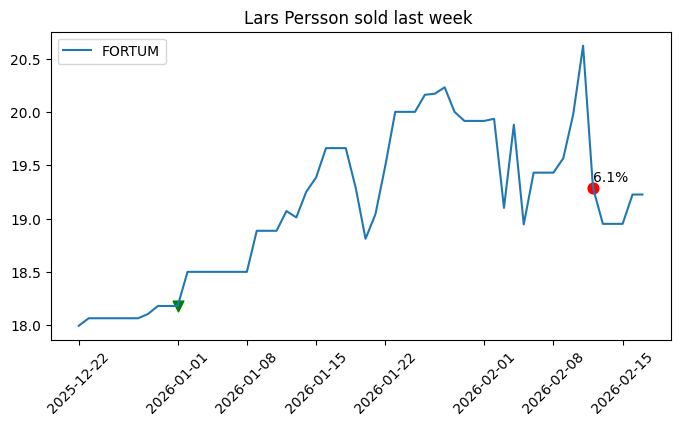

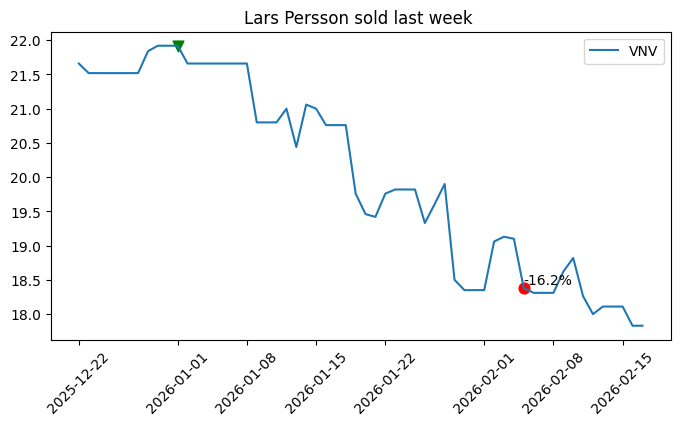

In [35]:
## mask the prices, so they fit with the buy and sells and are not too long back in history
date_frame_days = 10 # days before and after 
range_min = bs['BuyDate'].min() - dt.timedelta(days=date_frame_days)
range_max = bs['LastSeen'].max() + dt.timedelta(days=date_frame_days)

mask = (prices.index >= range_min) & (prices.index < range_max)
masked_prices = prices.loc[mask, rec_sold['Instrument']].sort_index().dropna(how='all') ########## use this df for masked price analysis

for i in rec_sold.index:
    fig, ax = plt.subplots(figsize=[8,4])
    ax.set_title(rec_sold.Investor[i]+" sold last week ")
    ax.plot(masked_prices.iloc[:,i], label=rec_sold.Instrument[i])
    ax.scatter(rec_sold.BuyDate[i], rec_sold.BuyPrice[i], color='g', s=60, marker='v')
    ax.scatter(rec_sold.LastSeen[i], rec_sold.LastPrice[i], color='r', s=60)
    ax.text(rec_sold.LastSeen[i], rec_sold.LastPrice[i]*1.003, s=str(round(rec_sold.Return[i],1))+"%")
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend()
    if IN_NOTEBOOK:
        fig.show()
    else:
        st.pyplot(fig, width=600)